# 02 — Root-finding

Three classical algorithms with different speed / robustness tradeoffs:

- **Bisection** – guaranteed but slow ($\mathcal{O}(\log_2(b-a)/\text{tol})$ iterations).
- **Newton** – quadratic convergence near a simple root, but can diverge.
- **Secant** – superlinear (golden ratio) without needing the derivative.

We solve $x^2 - 2 = 0$ and $\cos x - x = 0$, which are the canonical demos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7, 4.5), "figure.dpi": 110, "axes.grid": True})

from numethods import bisection, newton, secant


## Computing $\sqrt{2}$

In [2]:
f = lambda x: x**2 - 2.0
fp = lambda x: 2*x

bs = bisection(f, 0.0, 2.0, tol=1e-12)
nw = newton(f, x0=2.0, fprime=fp)
sc = secant(f, 0.0, 2.0)

for name, r in [("bisection", bs), ("newton", nw), ("secant", sc)]:
    print(f'{name:10s}  root={r.root:.16f}  iters={r.iterations}  resid={r.residual:.2e}')


bisection   root=1.4142135623724243  iters=41  resid=1.90e-12
newton      root=1.4142135623730951  iters=5  resid=4.44e-16
secant      root=1.4142135623730947  iters=7  resid=8.88e-16


## Convergence histories on a single plot

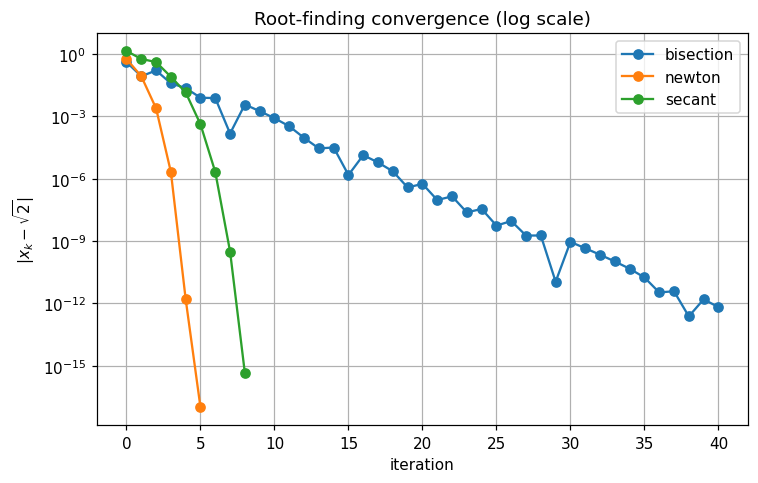

In [3]:
truth = np.sqrt(2)
fig, ax = plt.subplots()
for name, r in [("bisection", bs), ("newton", nw), ("secant", sc)]:
    errs = np.abs(np.array(r.history) - truth)
    errs = np.clip(errs, 1e-17, None)
    ax.semilogy(errs, 'o-', label=name)
ax.set_xlabel('iteration'); ax.set_ylabel(r'$|x_k - \sqrt{2}|$')
ax.set_title('Root-finding convergence (log scale)'); ax.legend()
fig.tight_layout(); plt.show()


Newton's halving slope vs bisection's straight-line decline is the visual signature of quadratic vs linear convergence.

## Solving $\cos x = x$

In [4]:
r = newton(lambda x: np.cos(x)-x, x0=0.5,
            fprime=lambda x: -np.sin(x) - 1)
print(f'fixed point: {r.root:.12f} in {r.iterations} iters')


fixed point: 0.739085133215 in 4 iters


This notebook demonstrates `numethods.rootfinding`.